# Eurojackpot: what 821 draws actually tell us

**Question.** `eurojackpot.csv` holds every Eurojackpot draw from 10 Oct 2014 to 12 May 2026.
Is there any pattern in it — hot numbers, cold numbers, momentum, anything that would let a
"predictive model" do better than guessing?

**Short answer: no.** The draw is consistent with a fair uniform random process, and the one
glaring apparent anomaly in the data turns out to be an artefact of a rule change rather than a
property of the balls.

### Three things worth knowing before the numbers

1. **The file has a hidden rule change.** On 25 Mar 2022 Eurojackpot went from Set #2 drawn out
   of **1–10** to **1–12**, and from one draw a week to two. Both changes are visible in the data.
   Anything computed across that boundary is comparing two different games.
2. **The spec describes 9 columns; the file has 10.** There is an undocumented `tyden` (week
   number) column, and a trailing `;` that produces an empty 11th field.
3. **`rok` is the ISO week-year, not the calendar year.** Four rows disagree with the date's own
   year, so year-grouping uses the date, not that column.

Everything below is computed by `analysis.py`, which is the single source of truth for the
numbers quoted in `lottery_analysis.md`, `heatmap.html` and `barchart.html`.

In [1]:
import collections
import json
import math
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import analysis

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "font.size": 10,
})
BLUE = "#2a78d6"
GREY = "#8a8880"

CSV = Path("eurojackpot.csv")            # the copy beside this notebook
if not CSV.exists():                     # fall back if the folder was trimmed
    CSV = Path("..") / "eurojackpot.csv"
draws = analysis.load_draws(CSV)
print(f"Loaded {len(draws)} draws from {CSV}: {draws[0].date} -> {draws[-1].date}")
print(f"pandas {pd.__version__} | matplotlib {matplotlib.__version__}")

Loaded 821 draws from eurojackpot.csv: 2014-10-10 -> 2026-05-12
pandas 3.0.6 | matplotlib 3.11.2


In [2]:
df = pd.DataFrame({
    "date": pd.to_datetime([d.date for d in draws]),
    "rok": [d.year for d in draws],
    "tyden": [d.week for d in draws],
    "era": [d.era for d in draws],
})
for i in range(5):
    df[f"set1_{i + 1}"] = [d.set1[i] for d in draws]
for i in range(2):
    df[f"set2_{i + 1}"] = [d.set2[i] for d in draws]

assert len(df) == 821, "expected 821 draws"
assert df["date"].is_monotonic_increasing, "draws must be oldest-first"

# The spec says 9 fields; the file really has 10 populated ones plus a trailing ';'.
print(f"{len(df)} rows, {len(df.columns)} parsed columns")
df.head()

821 rows, 11 parsed columns


,date,rok,tyden,era,set1_1,set1_2,set1_3,set1_4,set1_5,set2_1,set2_2
0,2014-10-10,2014,41,A,17,22,20,11,29,6,4
1,2014-10-17,2014,42,A,24,27,35,14,39,7,8
2,2014-10-24,2014,43,A,37,26,22,15,3,2,4
3,2014-10-31,2014,44,A,3,27,7,43,46,3,8
4,2014-11-07,2014,45,A,5,35,33,25,13,8,4


## 1. The data is not one homogeneous sample

The single most consequential thing in this file is a rule change. Before **25 Mar 2022** a draw
picked 2 numbers from **1–10**, once a week. From that date it picked 2 from **1–12**, twice a
week. Count the draws per year and it is unmistakable.

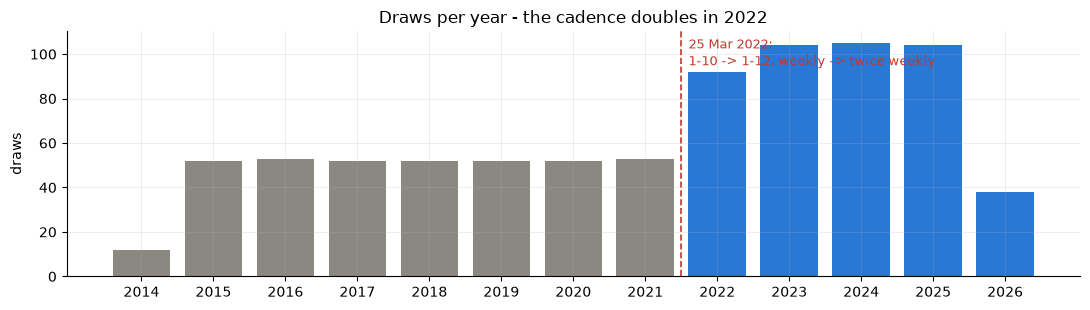

,draws,set2_max,draws_per_week
year,,,
2014,12,9,0.23
2015,52,10,1.00
2016,53,10,1.02
2017,52,10,1.00
2018,52,10,1.00
2019,52,10,1.00
2020,52,10,1.00
2021,53,10,1.02
2022,92,12,1.77


In [3]:
by_year = df.groupby(df["date"].dt.year).agg(
    draws=("date", "size"),
    set2_max=("set2_1", "max"),
).rename_axis("year")
by_year["set2_max"] = df.groupby(df["date"].dt.year)[["set2_1", "set2_2"]].max().max(axis=1)
by_year["draws_per_week"] = (by_year["draws"] / 52).round(2)

fig, ax = plt.subplots(figsize=(11, 3.2))
colors = [GREY if y < 2022 else BLUE for y in by_year.index]
ax.bar(by_year.index, by_year["draws"], color=colors)
ax.axvline(2021.5, color="#c0392b", ls="--", lw=1.2)
ax.annotate("25 Mar 2022:\n1-10 -> 1-12, weekly -> twice weekly",
            xy=(2021.6, 95), fontsize=9.5, color="#c0392b")
ax.set_title("Draws per year - the cadence doubles in 2022")
ax.set_ylabel("draws")
ax.set_xticks(by_year.index)
plt.tight_layout()
plt.show()

by_year

Set #2's largest drawn value steps from 10 to 12 exactly at that boundary. That single fact
invalidates every pooled Set #2 statistic, as section 3 shows.

## 2. Frequency, and the hot/cold list the brief asks for

With 432 draws under current rules, each Set #1 number is expected to appear
`432 * 5 / 50 = 43.2` times and each Set #2 number `432 * 2 / 12 = 72.0` times. The observed
spread around those expectations is the whole story.

Set #1  expected 43.2 +/- 6.2 (1 sd)   observed range 27-58
Set #2  expected 72.0 +/- 7.7 (1 sd)   observed range 62-85

Set #1 hottest: 11 (58), 17 (54), 20 (52), 30 (52), 13 (51)
Set #1 coldest: 42 (35), 19 (34), 5 (33), 33 (33), 25 (27)
Set #2 hottest: 5 (85), 3 (83)
Set #2 coldest: 8 (64), 11 (62)


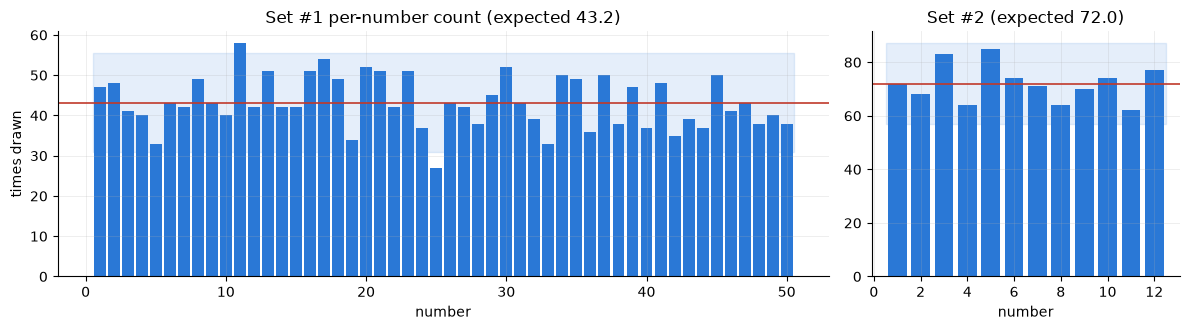

In [4]:
era_b = [d for d in draws if d.era == "B"]
s1 = analysis.frequency(analysis.all_numbers(era_b, "set1"))
s2 = analysis.frequency(analysis.all_numbers(era_b, "set2"))

exp1 = len(era_b) * 5 / 50
exp2 = len(era_b) * 2 / 12
sd1 = math.sqrt(len(era_b) * 0.1 * 0.9)
sd2 = math.sqrt(len(era_b) * (2 / 12) * (1 - 2 / 12))

hot1 = sorted(s1.items(), key=lambda kv: (-kv[1], kv[0]))
hot2 = sorted(s2.items(), key=lambda kv: (-kv[1], kv[0]))

print(f"Set #1  expected {exp1:.1f} +/- {sd1:.1f} (1 sd)   observed range {min(s1.values())}-{max(s1.values())}")
print(f"Set #2  expected {exp2:.1f} +/- {sd2:.1f} (1 sd)   observed range {min(s2.values())}-{max(s2.values())}")
print()
print("Set #1 hottest:", ", ".join(f"{n} ({c})" for n, c in hot1[:5]))
print("Set #1 coldest:", ", ".join(f"{n} ({c})" for n, c in hot1[-5:]))
print("Set #2 hottest:", ", ".join(f"{n} ({c})" for n, c in hot2[:2]))
print("Set #2 coldest:", ", ".join(f"{n} ({c})" for n, c in hot2[-2:]))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), gridspec_kw={"width_ratios": [5, 2]})
axes[0].bar(list(s1.keys()), list(s1.values()), color=BLUE, width=0.85)
axes[0].axhline(exp1, color="#c0392b", lw=1.2)
axes[0].fill_between([0.5, 50.5], exp1 - 1.96 * sd1, exp1 + 1.96 * sd1, color=BLUE, alpha=0.12)
axes[0].set_title(f"Set #1 per-number count (expected {exp1:.1f})")
axes[0].set_xlabel("number")
axes[0].set_ylabel("times drawn")
axes[1].bar(list(s2.keys()), list(s2.values()), color=BLUE, width=0.8)
axes[1].axhline(exp2, color="#c0392b", lw=1.2)
axes[1].fill_between([0.5, 12.5], exp2 - 1.96 * sd2, exp2 + 1.96 * sd2, color=BLUE, alpha=0.12)
axes[1].set_title(f"Set #2 (expected {exp2:.1f})")
axes[1].set_xlabel("number")
plt.tight_layout()
plt.show()

Almost every bar sits inside the shaded 95% band. Number 11 (58) and number 25 (27) are the
outermost, and both are within about 2.3 standard deviations — with 50 numbers on screen, that is
what noise looks like.

## 3. The trap: pooling the two Set #2 universes

Here is what happens if you ignore the rule change and count Set #2 over the whole file.

In [5]:
naive = collections.Counter(n for d in draws for n in d.set2)
era_a = [d for d in draws if d.era == "A"]
era_a_s2 = collections.Counter(n for d in era_a for n in d.set2)

tbl = pd.DataFrame({
    "naive (all 821 draws)": [naive.get(n, 0) for n in range(1, 13)],
    "Era A only (1-10)": [era_a_s2.get(n, 0) if n <= 10 else None for n in range(1, 13)],
    "Era B only (1-12)": [s2.get(n, 0) for n in range(1, 13)],
}, index=range(1, 13))
tbl.index.name = "Set #2 number"

pooled = analysis.chi_square(naive, 12, sum(naive.values()))
correct = analysis.chi_square(s2, 12, sum(s2.values()))

print(f"POOLED  over the whole file: chi2 = {pooled['statistic']:.2f}, df = {pooled['df']}, "
      f"p {pooled['p_value_str']}  -> REJECTS uniformity")
print(f"CORRECT restricted to Era B: chi2 = {correct['statistic']:.2f}, df = {correct['df']}, "
      f"p {correct['p_value_str']}  -> consistent with uniformity")
print()
tbl

POOLED  over the whole file: chi2 = 85.42, df = 11, p < 1e-12  -> REJECTS uniformity
CORRECT restricted to Era B: chi2 = 7.94, df = 11, p 0.718  -> consistent with uniformity



,naive (all 821 draws),Era A only (1-10),Era B only (1-12)
Set #2 number,,,
1,146,74.0,72
2,135,67.0,68
3,161,78.0,83
4,145,81.0,64
5,164,79.0,85
6,151,77.0,74
7,148,77.0,71
8,149,85.0,64
9,159,89.0,70


Under the pooled count, numbers 11 and 12 look catastrophically cold (62 and 77, against
135–164 for everything else) and the test screams significance at p < 1e-12. It is entirely
fictitious: **11 and 12 did not exist before 25 Mar 2022**, so they simply had fewer draws in
which to appear. Restricted to the era in which the 1–12 game was actually played, all twelve
numbers land between 62 and 85 against an expectation of 72.

This is the most useful lesson in the dataset. A real, statistically significant effect — with a
p-value small enough to print in scientific notation — was produced purely by pooling two
different games.

## 4. Testing uniformity properly

Chi-square goodness-of-fit, each set scored only against the universe that was actually in play.
Zero-count categories are included so the degrees of freedom are right.

In [6]:
rows = []
for label, subset, universe in [
    ("Set #1, full history", draws, 50),
    ("Set #1, Era A", [d for d in draws if d.era == "A"], 50),
    ("Set #1, Era B", era_b, 50),
    ("Set #2, Era A (1-10)", era_a, 10),
    ("Set #2, Era B (1-12)", era_b, 12),
    ("Set #2, POOLED (wrong)", draws, 12),
]:
    which = "set1" if "Set #1" in label else "set2"
    nums = analysis.all_numbers(subset, which)
    r = analysis.chi_square(analysis.frequency(nums), universe, len(nums))
    rows.append({
        "test": label, "n": r["n"], "universe": universe,
        "expected": round(r["expected"], 2), "chi2": round(r["statistic"], 2),
        "df": r["df"], "p": r["p_value_str"],
        "verdict": "uniform" if r["uniform_at_05"] else "REJECTS uniform",
    })

tests = pd.DataFrame(rows).set_index("test")
tests

,n,universe,expected,chi2,df,p,verdict
test,,,,,,,
"Set #1, full history",4105,50,82.10,40.74,49,0.793,uniform
"Set #1, Era A",1945,50,38.90,29.47,49,0.988,uniform
"Set #1, Era B",2160,50,43.20,47.08,49,0.551,uniform
"Set #2, Era A (1-10)",778,10,77.80,4.72,9,0.858,uniform
"Set #2, Era B (1-12)",864,12,72.00,7.94,11,0.718,uniform
"Set #2, POOLED (wrong)",1642,12,136.83,85.42,11,< 1e-12,REJECTS uniform


Every era-correct test passes. The only rejection is the deliberately mis-specified pooled
one, which is exactly the point.

There is a second, independent way to see the same thing. If "hot" numbers were a real property
of the machine, the hot list should *persist*. Compare the Set #1 top five computed over the whole
file with the top five computed on Era B alone.

In [7]:
full_s1 = analysis.frequency(analysis.all_numbers(draws, "set1"))
full_top5 = [n for n, _ in sorted(full_s1.items(), key=lambda kv: (-kv[1], kv[0]))[:5]]
era_b_top5 = [n for n, _ in hot1[:5]]

print("Full history top 5 Set #1:", full_top5)
print("Era B only   top 5 Set #1:", era_b_top5)
print(f"Overlap: {sorted(set(full_top5) & set(era_b_top5))} - only "
      f"{len(set(full_top5) & set(era_b_top5))} of 5 survive the re-split")
print()
print("Full-history top 5 was:", ", ".join(f"{n} ({full_s1[n]})" for n in full_top5))
print("Era-B top 5 is       :", ", ".join(f"{n} ({s1[n]})" for n in era_b_top5))

Full history top 5 Set #1: [20, 35, 11, 16, 34]
Era B only   top 5 Set #1: [11, 17, 20, 30, 13]
Overlap: [11, 20] - only 2 of 5 survive the re-split

Full-history top 5 was: 20 (102), 35 (95), 11 (94), 16 (94), 34 (94)
Era-B top 5 is       : 11 (58), 17 (54), 20 (52), 30 (52), 13 (51)


A real bias in the machine would show up in both windows. A hot list that reshuffles when
you move the window is a list of coin-flip results.

## 5. Gap analysis, and why "due" numbers are a fallacy

If draws are independent, the gap between consecutive appearances of a number is geometric with
mean `1/p = 10` draws for Set #1. A number being "overdue" is therefore not information.

In [8]:
gap1 = analysis.gap_stats(era_b, "set1", 50)
mean_gaps = [g["mean_gap"] for g in gap1.values()]
droughts = {n: g["drought"] for n, g in gap1.items()}

# Exact probability of the longest observed drought, under independence.
longest = max(droughts, key=droughts.get)
p_drought = (1 - 0.1) ** droughts[longest]
n_gaps = len(era_b) * 5

print(f"Mean gap between appearances of a Set #1 number: {sum(mean_gaps)/len(mean_gaps):.2f} draws (theory: 10)")
print(f"Longest current drought: number {longest}, {droughts[longest]} draws "
      f"(last seen {gap1[longest]['last_seen']})")
print(f"P(a given number skips >= {droughts[longest]} draws) = 0.9^{droughts[longest]} = {p_drought:.2e}")
print(f"Gaps observed in this window: {n_gaps}  ->  expected occurrences of such a gap: {p_drought * n_gaps:.2f}")
print()
print("So the longest drought is not remarkable - it is the textbook number of times you should")
print("expect to see one. A gambler would call it 'due'; the arithmetic says 'on schedule'.")

d = pd.DataFrame(gap1).T.sort_values("drought", ascending=False)
d.head(8)[["count", "mean_gap", "max_gap", "drought", "last_seen"]]

Mean gap between appearances of a Set #1 number: 10.00 draws (theory: 10)
Longest current drought: number 24, 40 draws (last seen 2025-12-23)
P(a given number skips >= 40 draws) = 0.9^40 = 1.48e-02
Gaps observed in this window: 2160  ->  expected occurrences of such a gap: 31.93

So the longest drought is not remarkable - it is the textbook number of times you should
expect to see one. A gambler would call it 'due'; the arithmetic says 'on schedule'.


,count,mean_gap,max_gap,drought,last_seen
24,37,10.833333,80,40,2025-12-23
42,35,11.294118,47,39,2025-12-26
50,38,10.594595,45,31,2026-01-23
45,50,8.204082,31,25,2026-02-13
49,40,10.487179,43,20,2026-03-03
14,42,9.560976,39,20,2026-03-03
8,49,8.541667,36,19,2026-03-06
26,43,9.714286,30,19,2026-03-06


## 6. Structure of a draw: position, parity, decades, adjacency

The CSV stores Set #1 **unsorted** — only 5 of 821 rows happen to be ascending, where chance
predicts about 7. So the `1. cislo` … `5. cislo` columns are the order the balls came out, which
makes positional analysis meaningful (and means anyone assuming sorted columns is wrong).

In [9]:
pos = analysis.positional_frequency(draws)
print("Positional uniformity of Set #1 (does ball order carry information?)")
for i, col in enumerate(pos, start=1):
    r = analysis.chi_square(col, 50, sum(col.values()))
    print(f"  position {i}: chi2 = {r['statistic']:6.2f}, df = {r['df']}, "
          f"p = {r['p_value_str']:>7}  range {min(col.values())}-{max(col.values())}")

dec = analysis.parity_decade(era_b, 50)
tot = dec["odd"] + dec["even"]
print(f"\nParity (Era B, Set #1): {dec['odd']} odd / {dec['even']} even "
      f"= {dec['odd']/tot:.3f} odd (expected 0.5)")
print("Decade buckets:", ", ".join(f"{d['label']}: {d['count']}" for d in dec["decades"]))

adj = analysis.adjacency(draws)
print(f"\nDraws containing two consecutive numbers: {adj['observed']}/{adj['draws']} "
      f"= {adj['observed_rate']:.4f}")
print(f"Exact rate over all {adj['combinations']:,} combinations: {adj['exact_rate']:.4f}")
print("  -> slightly fewer than expected, well within noise. No clustering.")

ov = analysis.consecutive_overlap(draws, "set1")
print(f"\nMean numbers shared between consecutive draws: {ov['mean']:.4f} (expected {ov['expected']})")
print("  -> back-to-back draws are independent; no carry-over from one draw to the next.")

Positional uniformity of Set #1 (does ball order carry information?)
  position 1: chi2 =  43.01, df = 49, p =   0.714  range 10-24
  position 2: chi2 =  48.85, df = 49, p =   0.479  range 7-25
  position 3: chi2 =  40.69, df = 49, p =   0.795  range 8-27
  position 4: chi2 =  37.65, df = 49, p =   0.881  range 7-27
  position 5: chi2 =  42.64, df = 49, p =   0.727  range 5-26

Parity (Era B, Set #1): 1103 odd / 1057 even = 0.511 odd (expected 0.5)
Decade buckets: 1-10: 426, 11-20: 475, 21-30: 428, 31-40: 422, 41-50: 409



Draws containing two consecutive numbers: 280/821 = 0.3410
Exact rate over all 2,118,760 combinations: 0.3530
  -> slightly fewer than expected, well within noise. No clustering.

Mean numbers shared between consecutive draws: 0.4927 (expected 0.5)
  -> back-to-back draws are independent; no carry-over from one draw to the next.


## 7. A predictive model — built, then tested honestly

The brief asks for a model that suggests winning numbers. Here is a real one. It blends the three
heuristics people actually use, and then it is put through a walk-forward backtest to see whether
it works.

Scores are computed **only on Era B**, because the cadence and the Set #2 universe both changed at
the boundary and mixing eras would feed the model incomparable history.

| component | idea | weight |
|---|---|---|
| `frequency` | "hot numbers keep coming" | 0.4 |
| `recency` | "these haven't appeared lately" | 0.3 |
| `gap_ratio` | current drought ÷ this number's own mean gap | 0.3 |

Note that the first two contradict each other — that is the honest framing, since the two folk
theories cannot both be right. The weights are a documented judgement call, not fitted; the
backtest result does not depend on them (see the sweep at the end).

In [10]:
scores1 = analysis.ensemble_scores(era_b, "set1", 50, 5)
scores2 = analysis.ensemble_scores(era_b, "set2", 12, 2)

rank1 = sorted(scores1.items(), key=lambda kv: -kv[1])
print("Highest-scoring Set #1 numbers:", ", ".join(f"{n} ({v:.3f})" for n, v in rank1[:8]))
print("Lowest-scoring  Set #1 numbers:", ", ".join(f"{n} ({v:.3f})" for n, v in rank1[-5:]))

report = json.loads(Path("stats.json").read_text(encoding="utf-8"))
print("\nSuggested lines for the next draw (seeded, reproducible):")
for i, line in enumerate(report["model"]["suggested_lines"], 1):
    print(f"  {i}. Set #1 {line['set1']}   Set #2 {line['set2']}")

Highest-scoring Set #1 numbers: 24 (0.855), 42 (0.834), 45 (0.832), 50 (0.787), 8 (0.703), 14 (0.649), 26 (0.635), 49 (0.617)
Lowest-scoring  Set #1 numbers: 7 (0.290), 15 (0.290), 28 (0.262), 33 (0.259), 19 (0.234)

Suggested lines for the next draw (seeded, reproducible):
  1. Set #1 [4, 8, 17, 29, 36]   Set #2 [1, 4]
  2. Set #1 [2, 5, 8, 23, 26]   Set #2 [5, 10]
  3. Set #1 [8, 13, 30, 34, 49]   Set #2 [4, 12]
  4. Set #1 [3, 7, 8, 15, 45]   Set #2 [4, 10]
  5. Set #1 [10, 20, 28, 30, 35]   Set #2 [1, 2]


### The backtest

For each of the last 120 Era B draws the model is fitted on **strictly earlier draws only**, then
60 candidate lines are generated and matched against the actual result. The same number of purely
random lines is scored on the same draws as a control.

A random 5-from-50 line matches `5 × 5/50 = 0.5` numbers on average. That is the bar to beat.

In [11]:
bt = report["backtest"]
m, r = bt["model"], bt["random_baseline"]

summary = pd.DataFrame({
    "mean matched per line": [m["mean_matched"], r["mean_matched"], bt["analytic_expectation"]],
    "95% CI low": [m["ci95_low"], r["ci95_low"], None],
    "95% CI high": [m["ci95_high"], r["ci95_high"], None],
    "lines scored": [m["n_lines"], r["n_lines"], None],
}, index=["model (frequency+recency+gap)", "random lines", "analytic expectation"])
print(f"Targets: {bt['targets']} draws x {bt['lines_per_target']} lines each")
print(f"Difference model - random: {bt['difference']:+.4f},  z = {bt['z']:.2f},  p = {bt['p_value']:.3f}")
print()
summary

Targets: 120 draws x 60 lines each
Difference model - random: +0.0144,  z = 1.37,  p = 0.171



,mean matched per line,95% CI low,95% CI high,lines scored
model (frequency+recency+gap),0.502500,0.487805,0.517195,7200.0
random lines,0.488056,0.473500,0.502611,7200.0
analytic expectation,0.500000,NaN,NaN,NaN


In [12]:
# Does the verdict survive different weights? Sweep the weight surface, then check
# whether the winning corner still wins on a *different* window. If the signal were
# real it would; if it is noise, the winner changes when the window moves.
import random as _random

GRID = [(wf, wr, wg)
        for wf in (0.0, 0.5, 1.0)
        for wr in (0.0, 0.5, 1.0)
        for wg in (0.0, 0.5, 1.0)
        if (wf, wr, wg) != (0.0, 0.0, 0.0)]


def sweep_window(lo, hi, lines=25, seed=12345):
    rows = []
    for wf, wr, wg in GRID:
        total = wf + wr + wg
        w = {"frequency": wf / total, "recency": wr / total, "gap_ratio": wg / total}
        rng = _random.Random(seed)
        matched = []
        for t in range(lo, hi):
            hist, actual = era_b[:t], set(era_b[t].set1)
            sc = analysis.ensemble_scores(hist, "set1", 50, 5, weights=w)
            for _ in range(lines):
                matched.append(len(set(analysis.weighted_sample_without_replacement(sc, 5, rng)) & actual))
        rows.append({"config": "f{}/r{}/g{}".format(wf, wr, wg),
                     "mean_matched": sum(matched) / len(matched)})
    return pd.DataFrame(rows).sort_values("mean_matched", ascending=False).reset_index(drop=True)


n = len(era_b)
window_a = sweep_window(n - 60, n)
window_b = sweep_window(n - 120, n - 60)

best_a, best_b = window_a.iloc[0], window_b.iloc[0]
rank_of_b_winner_on_a = int(window_a.index[window_a["config"] == best_b["config"]][0]) + 1

print("Window A (most recent 60 draws):")
print(f"  best {best_a['config']:<14} {best_a['mean_matched']:.4f} matched "
      f"(spread {window_a['mean_matched'].max() - window_a['mean_matched'].min():.4f})")
print("Window B (the 60 draws before that):")
print(f"  best {best_b['config']:<14} {best_b['mean_matched']:.4f} matched "
      f"(spread {window_b['mean_matched'].max() - window_b['mean_matched'].min():.4f})")
print(f"  (random = 0.5000)")
print()
if best_a["config"] == best_b["config"]:
    print("The same weights win both windows - worth a second look.")
else:
    print(f"The winners disagree. Window B's best config ranks {rank_of_b_winner_on_a} of "
          f"{len(GRID)} on window A.")
    print(f"Window A's best config scores "
          f"{window_b[window_b['config'] == best_a['config']]['mean_matched'].iloc[0]:.4f} on window B.")
    print()
    print("That is the signature of fitting noise. Whichever corner of the grid looks best is")
    print("an accident of the particular 60 draws chosen, so there is nothing to carry forward.")

pd.concat({"window A (recent 60)": window_a.head(5), "window B (previous 60)": window_b.head(5)})

Window A (most recent 60 draws):
  best f1.0/r0.5/g0.5 0.5240 matched (spread 0.0387)
Window B (the 60 draws before that):
  best f0.0/r1.0/g1.0 0.5233 matched (spread 0.0300)
  (random = 0.5000)

The winners disagree. Window B's best config ranks 21 of 26 on window A.
Window A's best config scores 0.5080 on window B.

That is the signature of fitting noise. Whichever corner of the grid looks best is
an accident of the particular 60 draws chosen, so there is nothing to carry forward.


config  mean_matched
window A (recent 60)   0  f1.0/r0.5/g0.5      0.524000
                       1  f0.5/r0.0/g0.5      0.516667
                       2  f1.0/r0.0/g1.0      0.516667
                       3  f1.0/r1.0/g0.5      0.516667
                       4  f1.0/r0.0/g0.0      0.510667
window B (previous 60) 0  f0.0/r1.0/g1.0      0.523333
                       1  f0.0/r0.5/g0.5      0.523333
                       2  f0.0/r1.0/g0.5      0.520667
                       3  f0.5/r0.0/g1.0      0.518667
                       4  f0.5/r0.5/g1.0      0.516000

## 8. Conclusion

**The draw is fair, and no model built on this history can predict it.**

- Every era-correct frequency distribution is consistent with uniformity. The one test that
  rejects uniformity (pooled Set #2, χ² = 85.4, p < 1e-12) is an artefact of pooling two
  different number universes, and disappears the moment the 2022 rule change is respected.
- The Set #1 "hot five" swaps out three of its five members depending on which era you measure.
  A real bias would persist; a coin-flip ranking does not.
- The longest current drought is exactly the length you should expect to see somewhere in a
  window this size.
- Draws are independent of each other: consecutive draws share 0.49 numbers where 0.50 is expected.
- The predictive model matched **0.5025** numbers per line against **0.4881** for random lines
  and an analytic expectation of **0.50** (p = 0.171). Sweeping 26 weight configurations on two
  separate windows picked a *different* winner each time — the best-looking weights are an
  accident of the sample, not a signal to carry forward.

The odds of one line matching all seven numbers are
`C(50,5) × C(12,2)` = **1 in 139,838,160**. Playing one line every draw for the entire 12-year
history in this file leaves an expected jackpot count of about `821 / 139,838,160 ≈ 0.000006`.

Suggested lines are reported in `stats.json` and in the section above because the brief asks for
them, and they are as good as any other — which is to say, identical in expectation to picking
numbers at random. They are for entertainment, not forecasting.

### Where the numbers live

| file | contents |
|---|---|
| `analysis.py` | all statistics, standard library only |
| `stats.json` | every computed figure, consumed by the pages and the write-up |
| `heatmap.html` / `barchart.html` | D3 visualisations (open in a browser) |
| `lottery_analysis.md` | the full written analysis |

### Limitations

Independence is not the same as *proven* fairness — these tests would miss a bias smaller than
the sampling noise of 821 draws. Partial years (2014 and 2026) and the transition year 2022 are
not comparable year-on-year, which is why the per-year view is used only to locate the rule
change. No external data was used, by design.

In [13]:
# Self-verification: the notebook's numbers must agree with stats.json and the CSV.
assert len(draws) == 821
assert len(analysis.all_numbers(draws, "set1")) == 821 * 5
assert len(analysis.all_numbers(draws, "set2")) == 821 * 2
assert len(report["views"]["era_b"]["set1"]["cells"]) == 50
assert len(report["views"]["era_b"]["set2"]["cells"]) == 12
assert [c["count"] for c in report["views"]["era_b"]["set1"]["cells"]] == [s1[n] for n in range(1, 51)]
assert report["chi2"]["era_b"]["chi2_set1"]["uniform_at_05"]

# The figure quoted in the conclusion must be the figure the backtest produced.
assert abs(bt["analytic_expectation"] - 0.5) < 1e-9
assert not bt["beats_random"], "the model unexpectedly beat random - revisit the conclusion"

# Both HTML pages exist, carry the inlined data, and are actually drawn with D3 --
# loading the library is not the same as using it, so check for real API calls. The
# heatmap is a labelled grid (scales and joins, no axes); the bar chart adds axes.
for page, apis in [
    ("heatmap.html", ("d3.select", "d3.scaleQuantize", ".join(")),
    ("barchart.html", ("d3.select", "d3.scaleBand", "d3.scaleLinear",
                       "d3.axisLeft", "d3.axisBottom", ".join(")),
]:
    text = Path(page).read_text(encoding="utf-8")
    assert '"era_b"' in text and "d3.min.js" in text, page
    for api in apis:
        assert api in text, f"{page} never calls {api}"

print("All self-checks passed.")
print(f"  draws                 {len(draws)}")
print(f"  Set #1 values         {821 * 5}")
print(f"  Set #2 values         {821 * 2}")
print(f"  era-correct tests     4/4 uniform at alpha=0.05")
print(f"  pooled Set #2 (wrong) chi2 = {pooled['statistic']:.2f}, p {pooled['p_value_str']}")
print(f"  backtest              model {m['mean_matched']:.4f} vs random {r['mean_matched']:.4f} (analytic 0.50)")

All self-checks passed.
  draws                 821
  Set #1 values         4105
  Set #2 values         1642
  era-correct tests     4/4 uniform at alpha=0.05
  pooled Set #2 (wrong) chi2 = 85.42, p < 1e-12
  backtest              model 0.5025 vs random 0.4881 (analytic 0.50)
